# Titanic Dataset Complete Exploratory Data Analysis


# 1.0 **About Dataset**

The Titanic dataset contains passenger information from the RMS Titanic disaster of 1912. It is a classic dataset used for data analysis and machine learning tasks, especially classification.

### Key Features
- **PassengerId**: Unique identifier for each passenger
- **Survived**: Survival status (`0` = did not survive, `1` = survived)
- **Pclass**: Passenger class
- **Name**: Passenger name
- **Sex**: Gender
- **Age**: Age of the passenger
- **SibSp**: Number of siblings/spouses aboard
- **Parch**: Number of parents/children aboard
- **Ticket**: Ticket number
- **Fare**: Ticket fare
- **Cabin**: Cabin number
- **Embarked**: Port of embarkation

### Objective
The main goal of analyzing this dataset is to understand the factors that influenced survival, such as passenger class, age, gender, and fare.

## 1.1 Importing The Libraries

In [3]:
# importing pandas, numpy, seaborn and matplotlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## 1.2 Importing The Data And Exploring It

In [4]:
df = pd.read_csv(r"D:\OneDrive\Desktop\data-analysis-course-preply\projects\train.csv")

In [5]:
# checking the first 5 rows of the dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# check the last 5 rows of the dataset
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [7]:
# checking how many rows and columns are in the dataset
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 891 rows and 12 columns.


In [ ]:
# print all columns in the dataset
df.columns
# df.columns.tolist()

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [11]:
# we can also use the info() method to get a concise summary of the dataset, including the number of non-null values and data types for each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [13]:
# finding the missing values in the dataset
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [16]:
# let's check the duplicates in our dataset
df.duplicated().sum()

np.int64(0)

## Titanic Dataset Summary

- **Rows:** 891
- **Columns:** 12
- **Missing Values:**
  - `Age`: 177 missing values
  - `Cabin`: 687 missing values
  - `Embarked`: 2 missing values
- **Data Types:**
  - Integer (`int64`): 5 columns
  - Float (`float64`): 2 columns
  - Object (`object`): 5 columns
- **Duplicate Rows:** 0

### Summary

The Titanic dataset contains **891 rows** and **12 columns**. Most columns are complete, but the `Age`, `Cabin`, and `Embarked` columns contain missing values, with `Cabin` having the largest number of missing entries. The dataset includes numerical and categorical features represented by integer, float, and object data types. No duplicate rows are present, making the dataset ready for further preprocessing, such as handling missing values and encoding categorical variables before analysis or machine learning.

# 2.0 Dealing With Missing Values

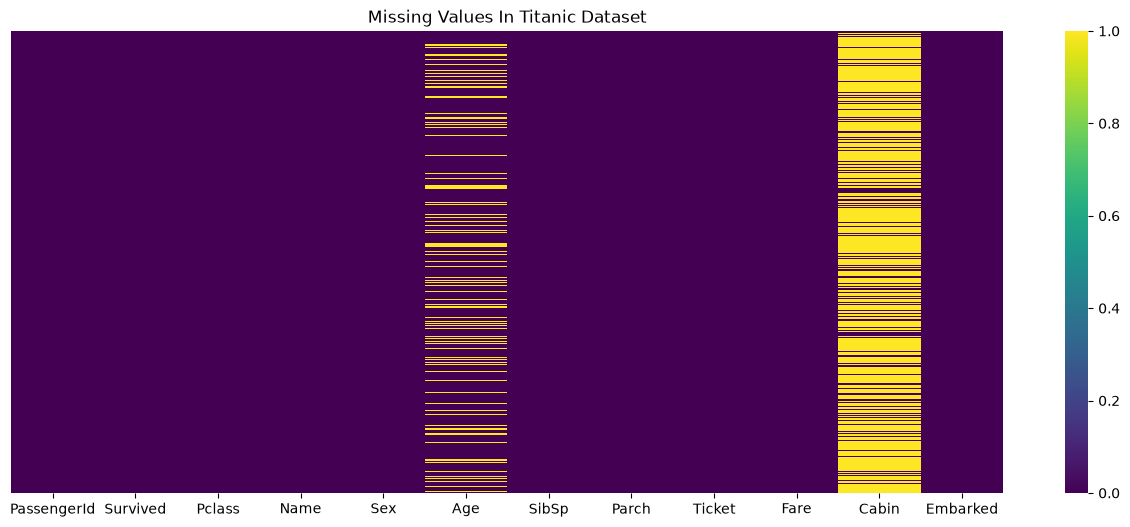

In [21]:
# let's plot missing values in the dataset

# step 1: adjusting figure size
plt.figure(figsize=(16,6))
# step 2: using seaborn to plot
sns.heatmap(df.isnull(), cmap="viridis", yticklabels=False)

# step 3: add labels
plt.title("Missing Values In Titanic Dataset")

# step 4: remove unnecessary output
plt.show()

In [22]:
# checking missing values by percentage
df.isnull().mean() * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

## Titanic Dataset Summary of Missing Values

The Titanic dataset contains a few missing values that need attention before analysis or modeling.

- **Age**: 177 missing values, which is about **19.87%** of the dataset
- **Cabin**: 687 missing values, which is about **77.10%** of the dataset
- **Embarked**: 2 missing values, which is about **0.22%** of the dataset

### Summary
The `Cabin` column has the highest number of missing values by far, while `Age` also has a significant amount of missing data. `Embarked` has only a very small number of missing entries. These missing values should be handled appropriately before further analysis.

### Dealing with Cabin column

In [24]:
# we'll drop Cabin column since it has maximum number of missing values
df.drop(columns=['Cabin'],inplace=True)
# df = df.drop(columns=['Cabin'])


In [25]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

### Dealing with Age column

In [27]:
# ignore irrelevant warnings
import warnings
warnings.filterwarnings("ignore")

In [32]:
# filling missing values in Age column with median value
df['Age'] = df['Age'].fillna(df['Age'].median())

### Dealing with Embarked Column

In [34]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [35]:
# dealing with missing values in Embarked column by filling them with mode value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


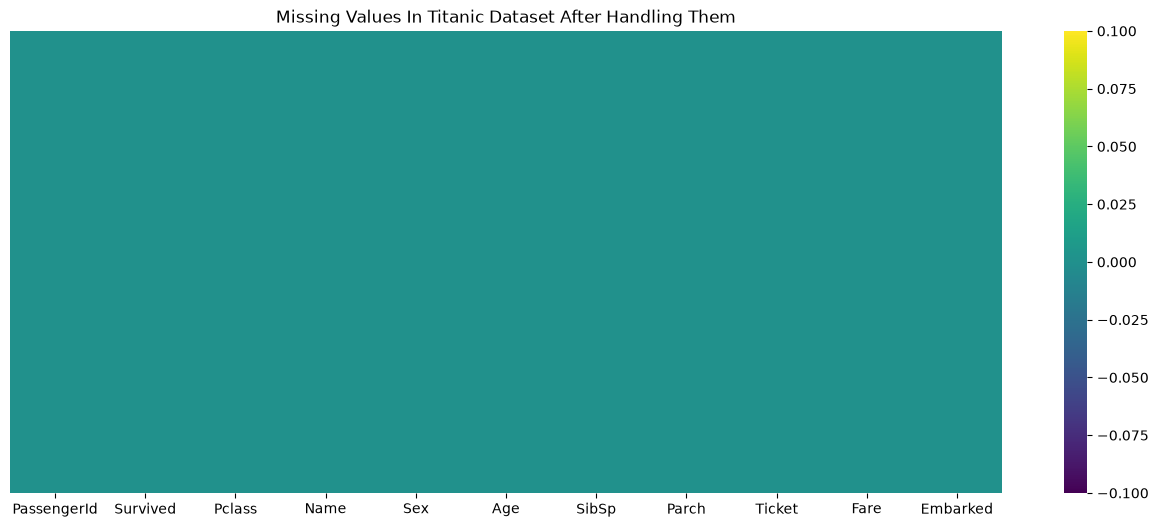

In [37]:
# plotting missing values after handling them
plt.figure(figsize=(16,6))
sns.heatmap(df.isnull(), cmap="viridis", yticklabels=False)
plt.title("Missing Values In Titanic Dataset After Handling Them")
plt.show()